Установка библиотек и импорты

In [51]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

# настройка графиков
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
})
PALETTE = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#0984E3', '#D63031']

Модели данных

In [56]:

@dataclass
class Vacancy:
    title: str
    salary_from: Optional[float]
    salary_to: Optional[float]
    currency: str = 'RUR'
    experience: str = ''
    schedule: str = ''
    employer: str = ''

    # средняя зп из вилки
    @property
    def salary_mid(self) -> Optional[float]:
        if self.salary_from and self.salary_to:
            return (self.salary_from + self.salary_to) / 2
        return self.salary_from or self.salary_to


# должность
@dataclass
class Position:
    name: str
    search_query: str | list
    count: int = 1
    vacancies: list = field(default_factory=list)
    benefits_monthly: float = 0

Класс для сбора данных с hh.ru API

In [57]:
import requests
import time

class TrudvsemApiCollector:
    """Сбор вакансий через открытый API портала Работа России."""

    BASE_URL = 'http://opendata.trudvsem.ru/api/v1/vacancies'

    def __init__(self, region_code: str = '7700000000000'):
        self.region_code = region_code
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'FlowerShopAnalysis/1.0',
            'Accept': 'application/json',
        })

    def search_vacancies(self, query: str, limit: int = 100) -> list[Vacancy]:
        url = f'{self.BASE_URL}/region/{self.region_code}'

        params = {
            'text': query,
            'limit': limit,
            'offset': 0,
        }

        try:
            resp = self.session.get(url, params=params, timeout=20)

            print('URL:', resp.url)
            print('Status:', resp.status_code)

            resp.raise_for_status()
            data = resp.json()

            return self._parse_items(data)

        except Exception as e:
            print(f'  [!] Ошибка API Работа России для "{query}": {e}')
            return []

    def _parse_items(self, data: dict) -> list[Vacancy]:
        vacancies = []

        # У Trudvsem обычно вакансии лежат внутри:
        # data['results']['vacancies']
        items = (
            data.get('results', {}).get('vacancies', [])
            or data.get('vacancies', [])
            or []
        )

        for item in items:
            # Иногда вакансия лежит внутри ключа 'vacancy'
            raw = item.get('vacancy', item)

            title = (
                raw.get('job-name')
                or raw.get('vacancy_name')
                or raw.get('name')
                or ''
            )

            employer = ''
            company = raw.get('company')
            if isinstance(company, dict):
                employer = company.get('name', '')
            elif isinstance(company, str):
                employer = company

            salary_from = (
                raw.get('salary_min')
                or raw.get('salary')
                or raw.get('salaryFrom')
                or raw.get('payment_from')
            )

            salary_to = (
                raw.get('salary_max')
                or raw.get('salaryTo')
                or raw.get('payment_to')
            )

            schedule = (
                raw.get('schedule')
                or raw.get('work_hours')
                or ''
            )

            experience = (
                raw.get('requirement', {}).get('experience')
                if isinstance(raw.get('requirement'), dict)
                else ''
            )

            v = Vacancy(
                title=title,
                salary_from=self._to_float(salary_from),
                salary_to=self._to_float(salary_to),
                currency='RUR',
                experience=experience or '',
                schedule=schedule or '',
                employer=employer or '',
            )

            if v.salary_mid and v.salary_mid > 0:
                vacancies.append(v)

        return vacancies

    @staticmethod
    def _to_float(value):
        if value in [None, '', 'null']:
            return None

        try:
            return float(value)
        except Exception:
            return None
    def collect_for_positions(self, positions: list[Position]) -> None:
        for pos in positions:
            queries = pos.search_query

            if isinstance(queries, str):
                queries = [queries]

            all_vacancies = []

            for query in queries:
                print(f'\nПоиск: "{query}" для позиции "{pos.name}" ...')
                found = self.search_vacancies(query)
                print(f'Найдено: {len(found)} вакансий с зарплатой')
                all_vacancies.extend(found)
                time.sleep(1)

            # Убираем дубликаты по названию, работодателю и зарплате
            unique = {}
            for v in all_vacancies:
                key = (
                    v.title,
                    v.employer,
                    v.salary_from,
                    v.salary_to
                )
                unique[key] = v

            pos.vacancies = list(unique.values())

            print(f'Итого для "{pos.name}": {len(pos.vacancies)} уникальных вакансий')

Запуск сбора данных

In [59]:
positions = [
    Position(
        'Флорист',
        ['флорист', 'продавец-флорист', 'цветы', 'цветочный'],
        count=2,
        benefits_monthly=7000
    ),

    Position(
        'Продавец-консультант',
        ['продавец-консультант', 'продавец', 'кассир', 'работник торгового зала'],
        count=2,
        benefits_monthly=5000
    ),

    Position(
        'Курьер',
        ['курьер', 'курьер доставка'],
        count=2,
        benefits_monthly=3000
    ),

    Position(
        'Администратор магазина',
        ['администратор магазина', 'администратор торгового зала', 'старший продавец'],
        count=1,
        benefits_monthly=8000
    ),

    Position(
        'SMM-менеджер',
        ['SMM', 'маркетолог', 'менеджер по рекламе', 'контент-менеджер'],
        count=1,
        benefits_monthly=3000
    ),

    Position(
        'Бухгалтер (аутсорс)',
        ['бухгалтер'],
        count=1,
        benefits_monthly=0
    ),
]

collector = TrudvsemApiCollector(region_code='7700000000000')
collector.collect_for_positions(positions)

MIN_VACANCIES_PER_POSITION = 3

bad_positions = [
    f'{pos.name}: {len(pos.vacancies)} вакансий'
    for pos in positions
    if len(pos.vacancies) < MIN_VACANCIES_PER_POSITION
]

if bad_positions:
    raise RuntimeError(
        'Недостаточно реальных данных из API Работа России. Анализ остановлен.\n\n'
        'Проблемные позиции:\n'
        + '\n'.join(bad_positions)
        + f'\n\nМинимум для анализа: {MIN_VACANCIES_PER_POSITION} вакансии на позицию.'
    )


Поиск: "флорист" для позиции "Флорист" ...
URL: http://opendata.trudvsem.ru/api/v1/vacancies/region/7700000000000?text=%D1%84%D0%BB%D0%BE%D1%80%D0%B8%D1%81%D1%82&limit=100&offset=0
Status: 200
Найдено: 2 вакансий с зарплатой

Поиск: "продавец-флорист" для позиции "Флорист" ...
URL: http://opendata.trudvsem.ru/api/v1/vacancies/region/7700000000000?text=%D0%BF%D1%80%D0%BE%D0%B4%D0%B0%D0%B2%D0%B5%D1%86-%D1%84%D0%BB%D0%BE%D1%80%D0%B8%D1%81%D1%82&limit=100&offset=0
Status: 200
Найдено: 0 вакансий с зарплатой

Поиск: "цветы" для позиции "Флорист" ...
URL: http://opendata.trudvsem.ru/api/v1/vacancies/region/7700000000000?text=%D1%86%D0%B2%D0%B5%D1%82%D1%8B&limit=100&offset=0
Status: 200
Найдено: 36 вакансий с зарплатой

Поиск: "цветочный" для позиции "Флорист" ...
URL: http://opendata.trudvsem.ru/api/v1/vacancies/region/7700000000000?text=%D1%86%D0%B2%D0%B5%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B9&limit=100&offset=0
Status: 200
Найдено: 10 вакансий с зарплатой
Итого для "Флорист": 42 уникальных в

Класс анализа зарплат и total cost

In [60]:
class SalaryAnalyzer:
    """Статистический анализ зарплат и расчёт total cost."""

    INSURANCE_RATE = 0.302  # ПФР 22% + ОМС 5.1% + ФСС 2.9% + НС 0.2%

    def __init__(self, positions: list[Position]):
        self.positions = positions
        self.df = self._build_dataframe()

    def _build_dataframe(self) -> pd.DataFrame:
      rows = []

      for pos in self.positions:
          for v in pos.vacancies:
              if v.salary_mid:
                  rows.append({
                      'position': pos.name,
                      'search_query': pos.search_query,
                      'vacancy_title': v.title,
                      'employer': v.employer,
                      'salary_from': v.salary_from,
                      'salary_to': v.salary_to,
                      'salary_mid': v.salary_mid,
                      'currency': v.currency,
                      'experience': v.experience,
                      'schedule': v.schedule,
                      'count_needed': pos.count,
                      'benefits_monthly': pos.benefits_monthly,
                  })

      return pd.DataFrame(rows)

    def summary_stats(self) -> pd.DataFrame:
        stats = self.df.groupby('position')['salary_mid'].agg(
            ['mean', 'median', 'std', 'min', 'max', 'count']
        ).round(0)
        stats.columns = ['Среднее', 'Медиана', 'Ст.откл.', 'Мин', 'Макс', 'N вакансий']
        return stats

    def total_cost_table(self) -> pd.DataFrame:
        rows = []
        for pos in self.positions:
            salaries = [v.salary_mid for v in pos.vacancies if v.salary_mid]
            if not salaries:
                continue
            median_salary = np.median(salaries)
            insurance = median_salary * self.INSURANCE_RATE
            benefits = pos.benefits_monthly
            total_per_person = median_salary + insurance + benefits
            total_all = total_per_person * pos.count

            rows.append({
                'Позиция': pos.name,
                'Кол-во': pos.count,
                'Медиана ЗП': round(median_salary),
                'Страх. взносы (30.2%)': round(insurance),
                'Бенефиты/мес.': round(benefits),
                'Total cost / чел.': round(total_per_person),
                'Total cost × штат': round(total_all),
            })
        return pd.DataFrame(rows)

    def experience_breakdown(self) -> pd.DataFrame:
        ct = pd.crosstab(self.df['position'], self.df['experience'], normalize='index') * 100
        return ct.round(1)

Запуск анализа и вывод таблиц

In [61]:
analyzer = SalaryAnalyzer(positions)

print('── Сводная статистика зарплат (₽/мес.) ──')
display(analyzer.summary_stats())

print('\n── Total Cost для компании ──')
tc = analyzer.total_cost_table()
display(tc)

total_monthly = tc['Total cost × штат'].sum()
total_annual = total_monthly * 12
print(f'\n ИТОГО :  {total_monthly:,.0f} ₽/мес.  |  {total_annual:,.0f} ₽/год')

── Сводная статистика зарплат (₽/мес.) ──


,Среднее,Медиана,Ст.откл.,Мин,Макс,N вакансий
position,,,,,,
SMM-менеджер,122164.0,100000.0,75960.0,39730.0,375000.0,36
Администратор магазина,82488.0,79000.0,7130.0,79000.0,100000.0,13
Бухгалтер (аутсорс),94600.0,90000.0,32190.0,40000.0,200000.0,92
Курьер,110257.0,100000.0,67549.0,27750.0,350000.0,124
Продавец-консультант,69433.0,70000.0,14137.0,45000.0,110000.0,112
Флорист,75953.0,69500.0,29884.0,37500.0,157500.0,42



── Total Cost для компании ──


,Позиция,Кол-во,Медиана ЗП,Страх. взносы (30.2%),Бенефиты/мес.,Total cost / чел.,Total cost × штат
0,Флорист,2,69500,20989,7000,97489,194978
1,Продавец-консультант,2,70000,21140,5000,96140,192280
2,Курьер,2,100000,30200,3000,133200,266400
3,Администратор магазина,1,79000,23858,8000,110858,110858
4,SMM-менеджер,1,100000,30200,3000,133200,133200
5,Бухгалтер (аутсорс),1,90000,27180,0,117180,117180



 ИТОГО :  1,014,896 ₽/мес.  |  12,178,752 ₽/год


In [62]:
# Общая таблица всех собранных вакансий
vacancies_df = analyzer.df.copy()

# Сначала сортируем по реальным названиям колонок
vacancies_df = vacancies_df.sort_values(
    by=['position', 'salary_mid'],
    ascending=[True, True]
).reset_index(drop=True)

# Потом переименовываем колонки для красивого вывода
vacancies_df = vacancies_df.rename(columns={
    'position': 'Должность в проекте',
    'salary_from': 'ЗП от',
    'salary_to': 'ЗП до',
    'salary_mid': 'Средняя ЗП по вилке',
    'experience': 'Опыт',
    'schedule': 'График',
    'count_needed': 'Нужно сотрудников',
    'benefits_monthly': 'Бенефиты в месяц'
})

display(vacancies_df)


file_name = 'all_vacancies_flower_shop.xlsx'

vacancies_df.to_excel(file_name, index=False)

print(f'Файл сохранён: {file_name}')

from google.colab import files
files.download(file_name)

,Должность в проекте,search_query,vacancy_title,employer,ЗП от,ЗП до,Средняя ЗП по вилке,currency,Опыт,График,Нужно сотрудников,Бенефиты в месяц
0,SMM-менеджер,"[SMM, маркетолог, менеджер по рекламе, контент...",SMM-специалист,"РОФ ""БЕЗ БАРЬЕРОВ""",39730.0,39730.0,39730.0,RUR,1,Режим гибкого рабочего времени,1,3000
1,SMM-менеджер,"[SMM, маркетолог, менеджер по рекламе, контент...",Контент-менеджер,"РОФ ""БЕЗ БАРЬЕРОВ""",39730.0,39730.0,39730.0,RUR,1,Полный рабочий день,1,3000
2,SMM-менеджер,"[SMM, маркетолог, менеджер по рекламе, контент...",Менеджер по рекламе,"""НИППОН СТИЛ ТРЕЙДИНГ КОРПОРЕЙШН""",40000.0,40000.0,40000.0,RUR,10,Полный рабочий день,1,3000
3,SMM-менеджер,"[SMM, маркетолог, менеджер по рекламе, контент...",маркетолог,"ФОНД ""В.Н.У.К.""",40650.0,40650.0,40650.0,RUR,1,Режим гибкого рабочего времени,1,3000
4,SMM-менеджер,"[SMM, маркетолог, менеджер по рекламе, контент...",Менеджер по рекламе,"ПРЕДСТАВИТЕЛЬСТВО ""ХУЭЙХУН""",45000.0,50000.0,47500.0,RUR,6,Полный рабочий день,1,3000
...,...,...,...,...,...,...,...,...,...,...,...,...
414,Флорист,"[флорист, продавец-флорист, цветы, цветочный]",Печатник флексографской печати,"ПАО ""ЛАМБУМИЗ""",100000.0,120000.0,110000.0,RUR,3,Сменная работа,2,7000
415,Флорист,"[флорист, продавец-флорист, цветы, цветочный]",Шеф-повар,ИП ЛЕ Т.,100000.0,120000.0,110000.0,RUR,3,Полный рабочий день,2,7000
416,Флорист,"[флорист, продавец-флорист, цветы, цветочный]",специалист по озеленению,"АНО ""КОНГРЕСС-БЮРО Г.МОСКВЫ""",132300.0,132300.0,132300.0,RUR,,Полный рабочий день,2,7000
417,Флорист,"[флорист, продавец-флорист, цветы, цветочный]",Автомаляр,Автосервис Лубань,150000.0,150000.0,150000.0,RUR,1,Полный рабочий день,2,7000


Файл сохранён: all_vacancies_flower_shop.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Класс визуализации

In [63]:
class StaffVisualizer:

    def __init__(self, analyzer: SalaryAnalyzer):
        self.analyzer = analyzer
        self.df = analyzer.df

    def plot_salary_boxplot(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        order = (self.df.groupby('position')['salary_mid']
                 .median().sort_values(ascending=True).index)

        bp = ax.boxplot(
            [self.df[self.df['position'] == p]['salary_mid'] / 1000 for p in order],
            labels=order, vert=False, patch_artist=True,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', alpha=0.4, markersize=4),
        )
        for patch, color in zip(bp['boxes'], PALETTE):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xlabel('Зарплата, тыс. ₽/мес.')
        ax.set_title('Распределение зарплат по позициям (Москва)', pad=15)
        ax.axvline(x=self.df['salary_mid'].median()/1000, color='gray',
                   linestyle='--', alpha=0.5, label='Общая медиана')
        ax.legend()
        plt.tight_layout()
        plt.show()

    def plot_total_cost(self):
        tc = self.analyzer.total_cost_table()
        fig, ax = plt.subplots(figsize=(12, 6))

        positions = tc['Позиция']
        y = np.arange(len(positions))

        salary = tc['Медиана ЗП'] / 1000
        insurance = tc['Страх. взносы (30.2%)'] / 1000
        benefits = tc['Бенефиты/мес.'] / 1000

        ax.barh(y, salary, 0.5, label='Оклад (gross)', color=PALETTE[0], alpha=0.85)
        ax.barh(y, insurance, 0.5, left=salary,
                label='Страховые взносы 30.2%', color=PALETTE[1], alpha=0.85)
        ax.barh(y, benefits, 0.5, left=salary + insurance,
                label='Бенефиты', color=PALETTE[2], alpha=0.85)

        for i, row in tc.iterrows():
            total = row['Total cost / чел.'] / 1000
            ax.text(total + 1, i, f'{total:.0f}k', va='center', fontweight='bold')

        ax.set_yticks(y)
        ax.set_yticklabels(positions)
        ax.set_xlabel('тыс. ₽/мес.')
        ax.set_title('Структура Total Cost на 1 сотрудника', pad=15)
        ax.legend(loc='lower right')
        plt.tight_layout()
        plt.show()

    def plot_budget_summary(self):
        tc = self.analyzer.total_cost_table()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        labels = tc['Позиция']
        values = tc['Total cost × штат'] / 1000

        ax1.pie(values, labels=None, autopct='%1.0f%%',
                colors=PALETTE[:len(labels)], startangle=90,
                pctdistance=0.75, textprops={'fontsize': 10})
        ax1.legend(labels, loc='lower left', fontsize=9)
        ax1.set_title(f'Доли в ФОТ\n(итого: {values.sum():.0f}k ₽/мес.)', pad=15)

        y = np.arange(len(labels))
        bars = ax2.barh(y, values, color=PALETTE[:len(labels)], alpha=0.85, height=0.5)
        ax2.set_yticks(y)
        ax2.set_yticklabels(labels)
        ax2.set_xlabel('тыс. ₽/мес.')
        ax2.set_title('Месячный бюджет по позициям (с учётом штата)', pad=15)
        for bar, val in zip(bars, values):
            ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}k', va='center', fontweight='bold')

        plt.tight_layout()
        plt.show()

    def plot_experience_heatmap(self):
        exp = self.analyzer.experience_breakdown()
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.heatmap(exp, annot=True, fmt='.0f', cmap='YlGnBu',
                    ax=ax, cbar_kws={'label': '% вакансий'}, linewidths=0.5)
        ax.set_title('Требуемый опыт по позициям, %', pad=15)
        ax.set_ylabel('')
        ax.set_xlabel('')
        plt.tight_layout()
        plt.show()

    def plot_salary_violin(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        order = (self.df.groupby('position')['salary_mid']
                 .median().sort_values(ascending=False).index.tolist())

        sns.violinplot(
            data=self.df, x='salary_mid', y='position', order=order,
            palette=PALETTE, inner='quartile', ax=ax, alpha=0.8,
            scale='width', cut=0
        )
        ax.set_xlabel('Зарплата, ₽/мес.')
        ax.set_ylabel('')
        ax.set_title('Плотность распределения зарплат', pad=15)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        plt.tight_layout()
        plt.show()

Генерация графиков

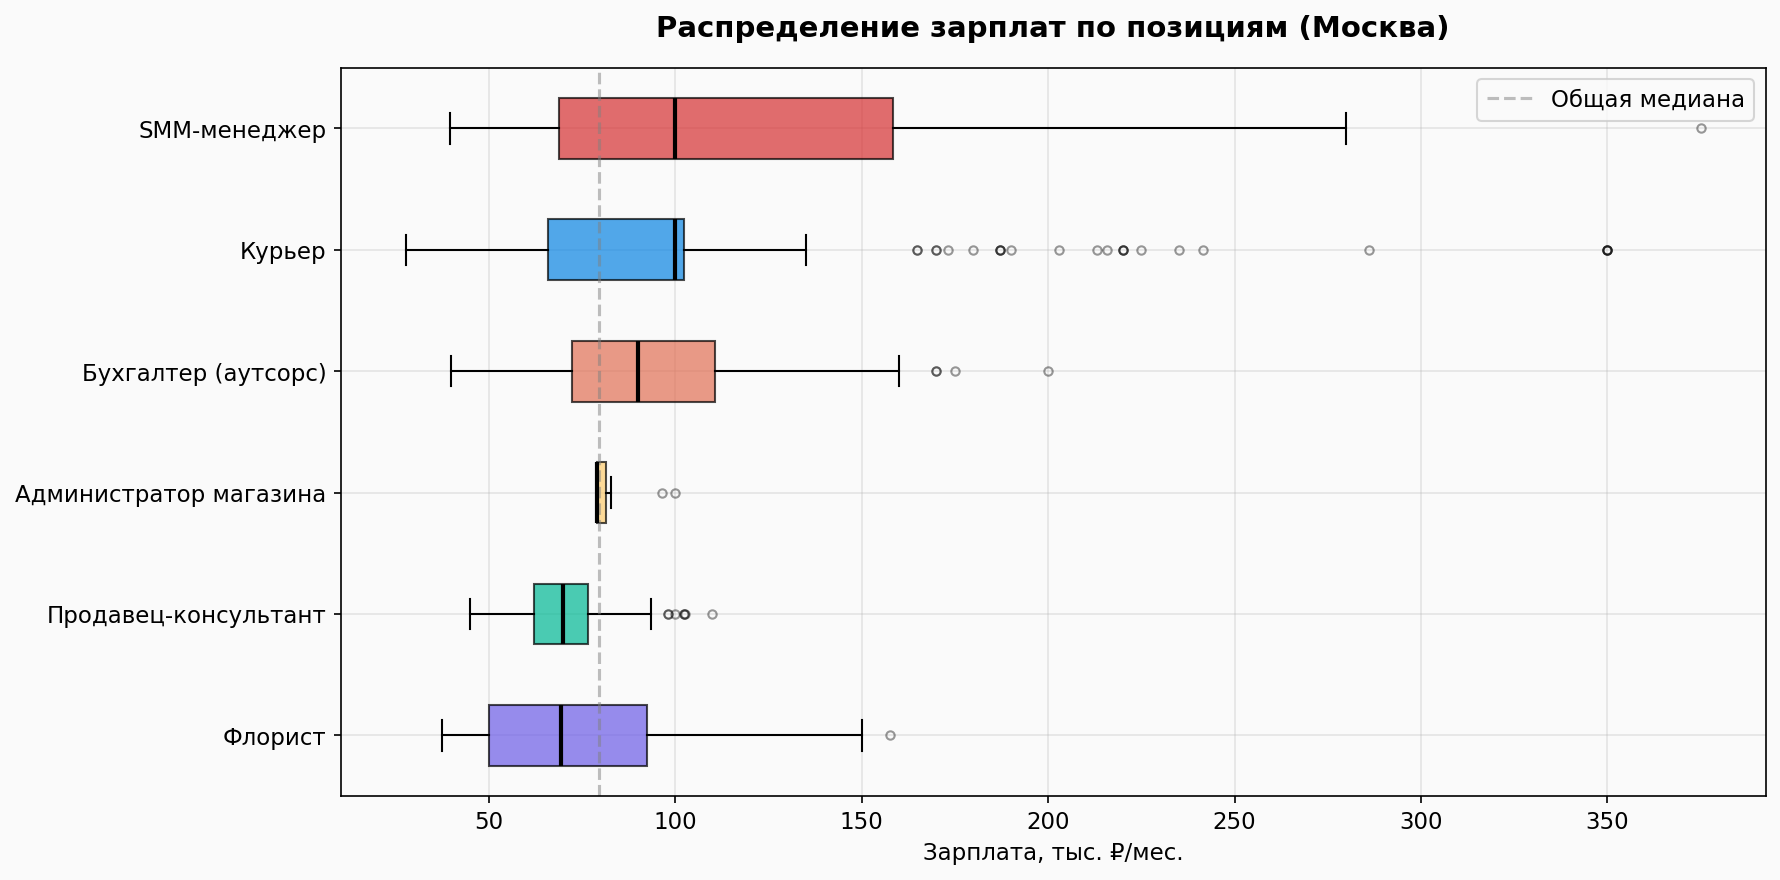

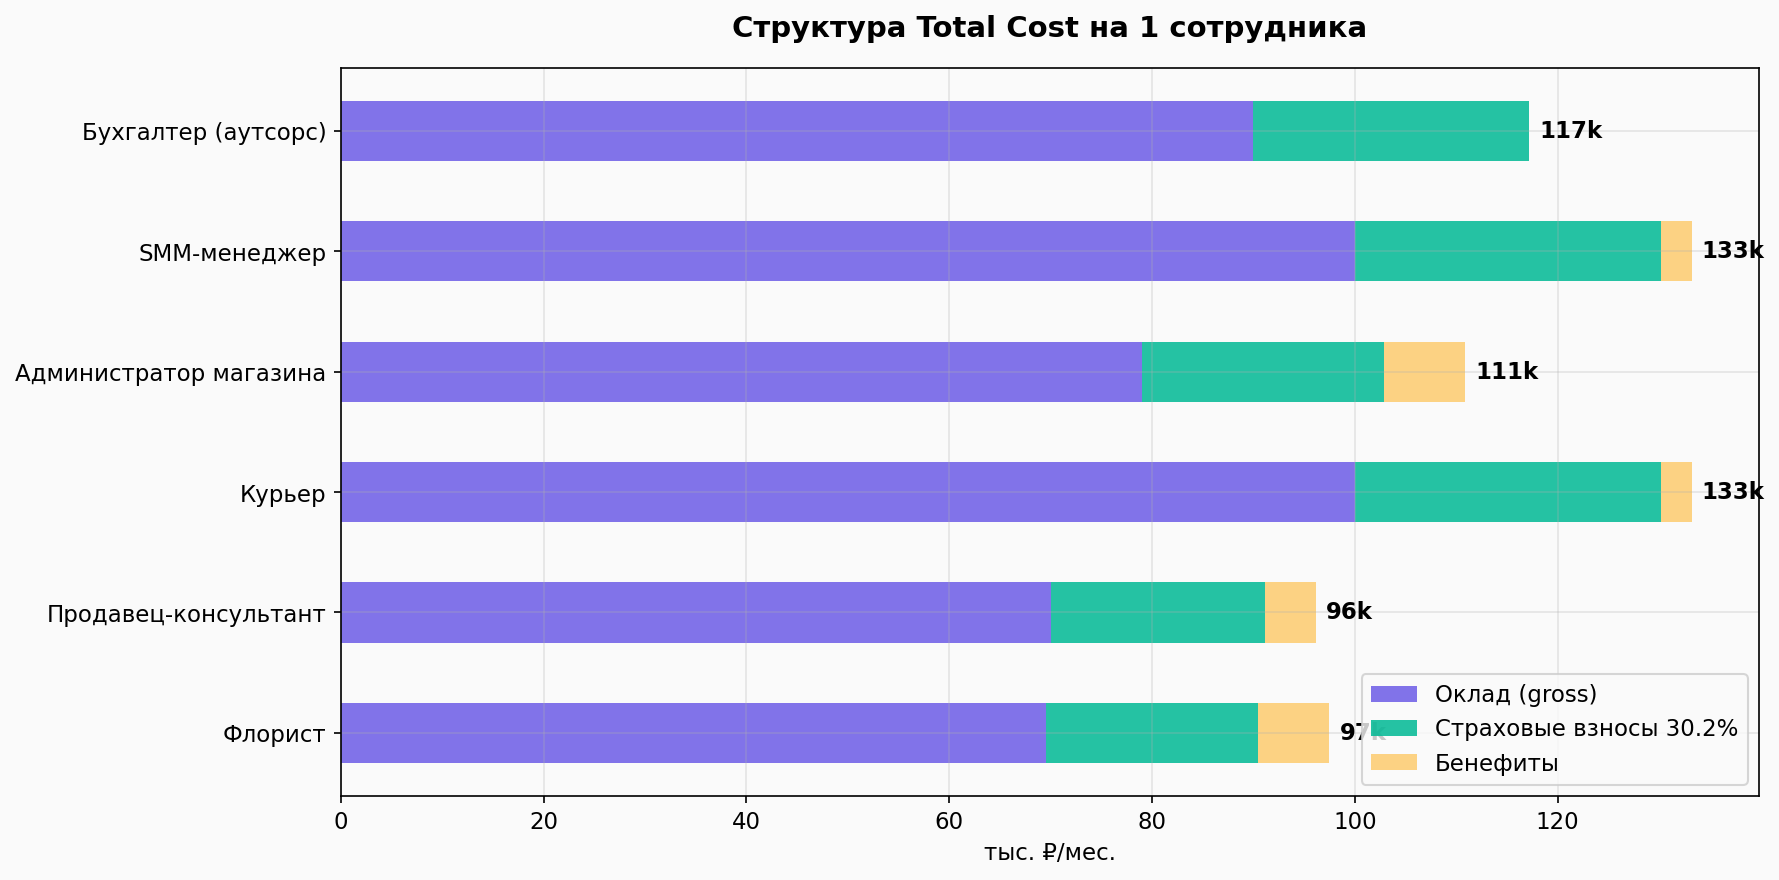

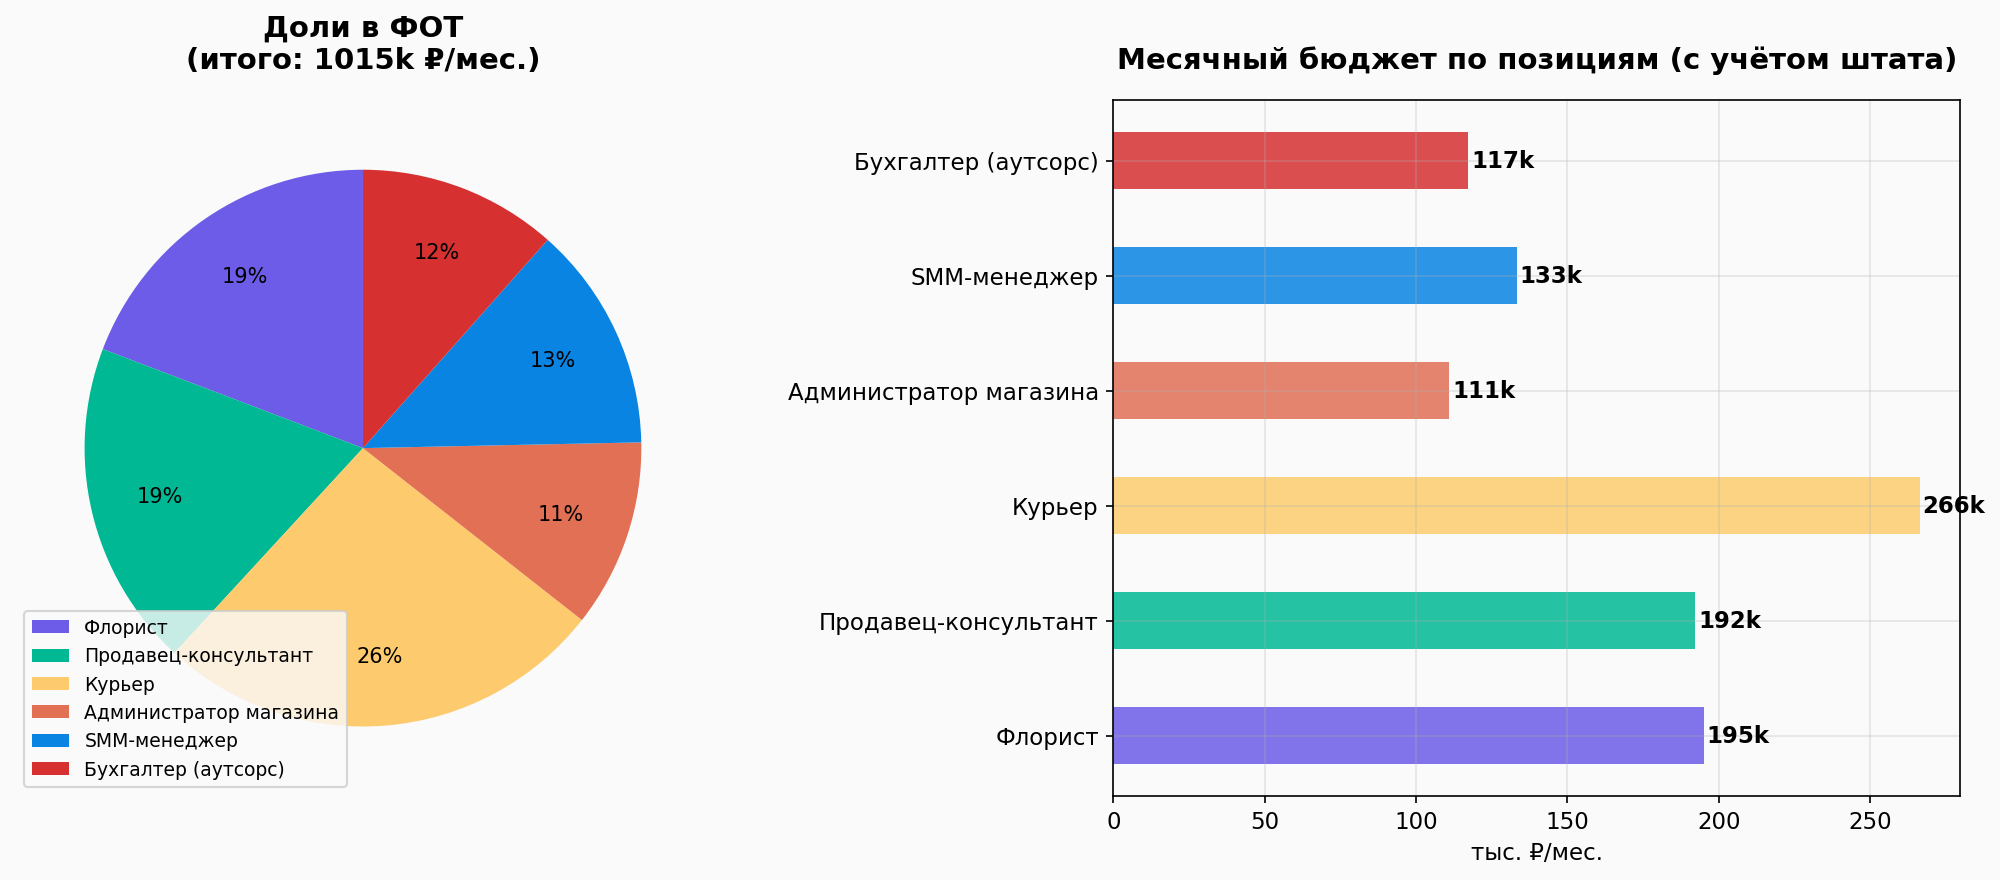

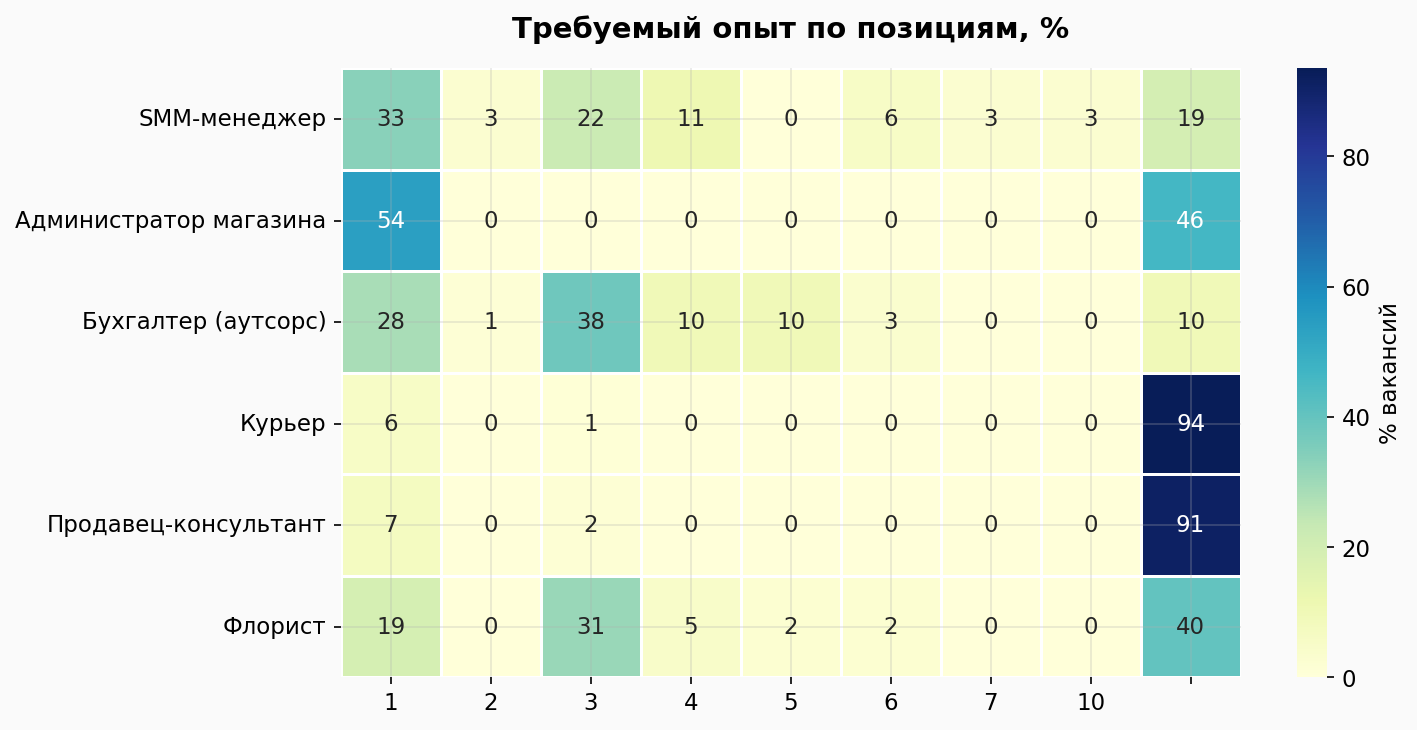

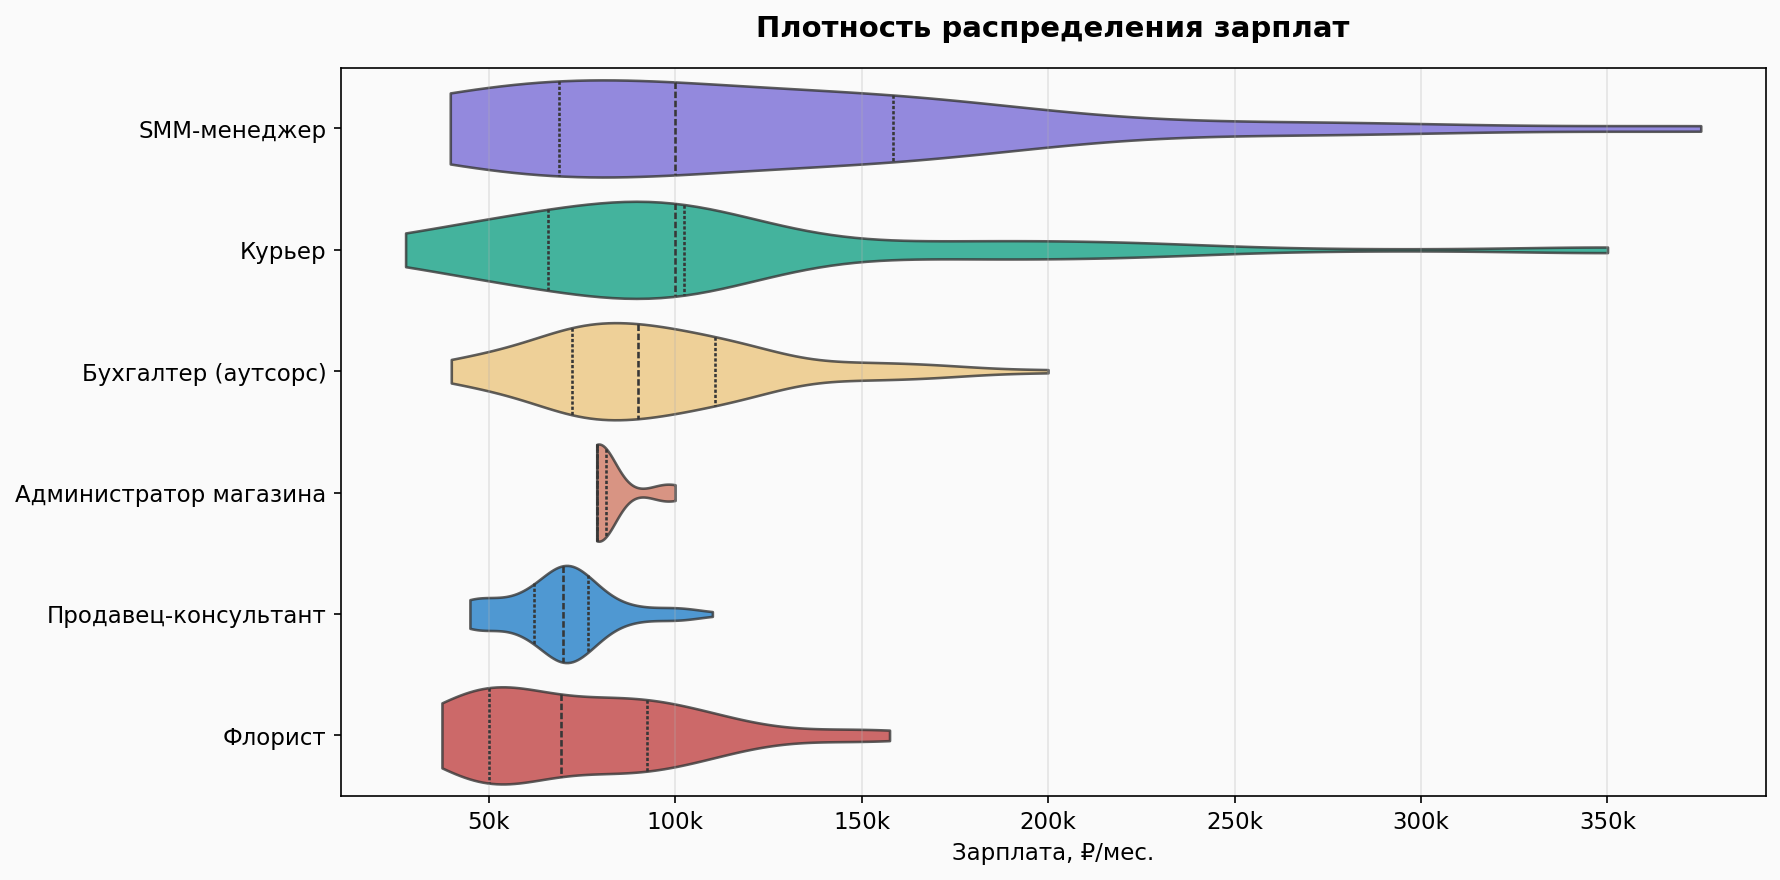

In [64]:
viz = StaffVisualizer(analyzer)

viz.plot_salary_boxplot()
viz.plot_total_cost()
viz.plot_budget_summary()
viz.plot_experience_heatmap()
viz.plot_salary_violin()